In [ ]:
# Dataset citation: AURORA SDG v5 Worldwide Set, DOI-level SDG target and goal labels for research articles (2009–2020), supplied source files in ../aurora/. The distributed files contain no author or formal publication citation; cite the dataset title and files as provided.

In [ ]:
# Imports and simple EDA helpers
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_ROOT = Path("..")

def inspect_table(df, name, preview_columns=None):
    print(f"\n{name}: {len(df):,} rows x {len(df.columns):,} columns")
    cols = preview_columns or list(df.columns[:8])
    shown = df[cols]
    display(pd.DataFrame({"column": shown.columns, "dtype": [str(x) for x in shown.dtypes],
                          "missing": shown.isna().sum().values,
                          "missing_%": (shown.isna().mean().values * 100).round(2),
                          "unique": shown.astype(str).nunique(dropna=True).values}))
    print(f"Duplicate rows on shown columns: {shown.astype(str).duplicated().sum():,}")
    display(shown.head(5))

def plot_counts(counts, title, xlabel="Class", ylabel="Rows"):
    counts = counts.sort_index()
    display(counts.rename("count").to_frame())
    ax = counts.plot(kind="bar", figsize=(11, 4), color="#4472C4")
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def text_stats(df, column):
    if column not in df.columns:
        return
    values = df[column].fillna("").astype(str)
    lengths = values.str.len()
    words = values.str.split().str.len()
    print(f"\nText field: {column}")
    display(pd.DataFrame({"characters": lengths.describe(), "words": words.describe()}))
    print("Empty text rows:", int(values.str.strip().eq("").sum()))

In [ ]:
# Load the CSV versions
files = {
    "target_long": DATA_ROOT / "aurora/aurora_sdg_v5_worldwide_set_doi_sdg_targets_2009-2020.csv",
    "target_wide": DATA_ROOT / "aurora/aurora_sdg_v5_worldwide_set_doi_sdg_targets_2009-2020-in-columns.csv",
    "abstract_sample_long": DATA_ROOT / "aurora/SAMPLE_aurora_sdg_v5_worldwide_set_doi_abstracts_sdg_targets_2009-2020.csv",
    "abstract_sample_wide": DATA_ROOT / "aurora/SAMPLE_aurora_sdg_v5_worldwide_set_doi_abstracts_sdg_targets_2009-2020-in-columns.csv",
}
frames = {name: pd.read_csv(path, low_memory=False) for name, path in files.items()}

In [ ]:
# File sizes and shapes
display(pd.DataFrame([{"file": name, "rows": len(frame), "columns": len(frame.columns)} for name, frame in frames.items()]))

,file,rows,columns
0,target_long,1391592,4
1,target_wide,1103960,188
2,abstract_sample_long,1000,7
3,abstract_sample_wide,1000,191


In [ ]:
# Target records table
long = frames["target_long"]
inspect_table(long, "Target records", ["doi", "sdg_target", "sdg_goal", "date"])


Target records: 1,391,592 rows x 4 columns


,column,dtype,missing,missing_%,unique
0,doi,object,0,0.0,1098161
1,sdg_target,object,0,0.0,169
2,sdg_goal,object,0,0.0,17
3,date,object,0,0.0,4151


Duplicate rows on shown columns: 0


,doi,sdg_target,sdg_goal,date
0,10.1002/j.1839-4655.2010.tb00165.x,1.1,SDG01,2010-01-01
1,10.1002/j.1839-4655.2010.tb00187.x,1.1,SDG01,2010-01-01
2,10.1002/joc.1872,1.1,SDG01,2010-01-01
3,10.1002/sd.407,1.1,SDG01,2010-01-01
4,10.1002/wcc.87,1.1,SDG01,2010-01-01


In [ ]:
# Wide target table
inspect_table(frames["target_wide"], "Target indicators", ["doi", "date", "SDG01", "SDG02", "SDG03"])


Target indicators: 1,103,960 rows x 188 columns


,column,dtype,missing,missing_%,unique
0,doi,object,0,0.00,1098161
1,date,object,0,0.00,4151
2,SDG01,float64,1047329,94.87,2
3,SDG02,float64,1077432,97.60,2
4,SDG03,float64,930034,84.25,2


Duplicate rows on shown columns: 4,607


,doi,date,SDG01,SDG02,SDG03
0,10.1 7239/jowr-2010.02.02.5,2010-01-01,NaN,NaN,NaN
1,10.1001/archophthalmol.2010.228,2010-01-01,NaN,NaN,NaN
2,10.1001/archpediatrics.2009.235,2010-01-01,NaN,NaN,1.0
3,10.1001/archpediatrics.2009.237,2010-01-01,NaN,NaN,NaN
4,10.1001/archsurg.2010.125,2010-01-01,NaN,NaN,NaN


In [ ]:
# Abstract sample table
abstracts = frames["abstract_sample_long"]
inspect_table(abstracts, "Abstract sample", ["doi", "title", "abstract_cleaned", "sdg_goal"])


Abstract sample: 1,000 rows x 7 columns


,column,dtype,missing,missing_%,unique
0,doi,object,0,0.0,1000
1,title,object,0,0.0,1000
2,abstract_cleaned,object,0,0.0,1000
3,sdg_goal,object,0,0.0,17


Duplicate rows on shown columns: 0


,doi,title,abstract_cleaned,sdg_goal
0,10.2217/hiv.09.53,Obstructive lung disease and HIV/AIDS in the H...,Early in the AIDS epidemic opportunistic lung ...,SDG03
1,10.1055/s-0030-1250034,Quad driving life-endangering fun? A medical a...,Aim: Quads or all-terrain vehicles do not seem...,SDG03
2,10.1017/CBO9780511750786.015,The Lazarus Effect: The (RED) Campaign and cre...,"com. The Lazarus Effect video, the (RED) Campa...",SDG03
3,10.5565/rev/ec/v28n3.99,Audiovisual production of scientific-education...,In the production of audiovisual material for ...,SDG04
4,10.1080/13504620903504099,Between knowing what is right and knowing that...,This contribution provides an 'outside' commen...,SDG04


In [ ]:
# Wide abstract sample table
inspect_table(frames["abstract_sample_wide"], "Abstract indicators", ["doi", "title", "abstract_cleaned", "SDG01", "SDG02"])


Abstract indicators: 1,000 rows x 191 columns


,column,dtype,missing,missing_%,unique
0,doi,object,125,12.5,876
1,title,object,0,0.0,1000
2,abstract_cleaned,object,0,0.0,1000
3,SDG01,float64,955,95.5,2
4,SDG02,float64,971,97.1,2


Duplicate rows on shown columns: 0


,doi,title,abstract_cleaned,SDG01,SDG02
0,NaN,Status of eco-design in thai furniture industry,Furniture manufacturing is known to have consi...,NaN,NaN
1,NaN,Treatment of dyeing industry effluents by usin...,Adsorption as a water and wastewater treatment...,NaN,NaN
2,NaN,Concentrated heat storage for solar heating,The FP7 sponsored DEARSUN project (short for '...,NaN,NaN
3,NaN,Drinking water safety and standards for drinki...,Safe drinking water is one of the essentials o...,NaN,NaN
4,10.1007/s10459-009-9203-1,Are Asian international medical students just ...,A wide variety of countries are seeking to att...,NaN,NaN


,count
sdg_goal,
SDG01,67905
SDG02,27718
SDG03,176885
SDG04,63994
SDG05,29188
SDG06,125915
SDG07,61945
SDG08,44265
SDG09,31858


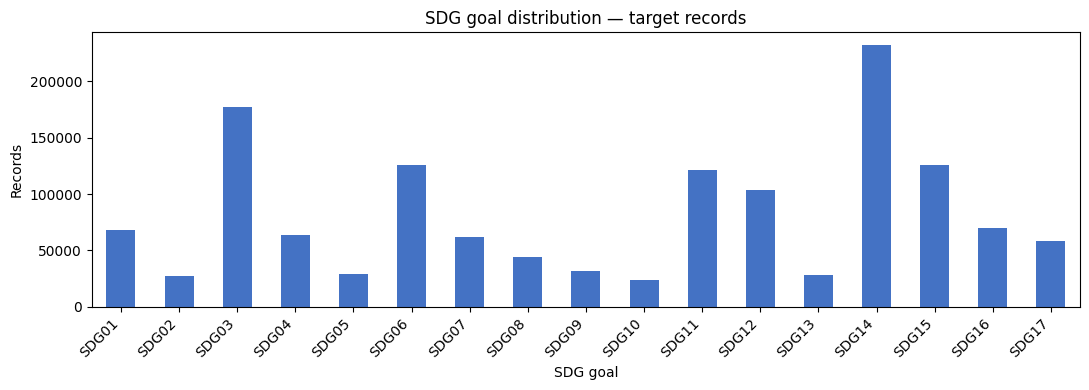

In [ ]:
# Goal counts
plot_counts(long["sdg_goal"].value_counts(), "SDG goal distribution — target records", "SDG goal", "Records")

,count
sdg_goal,
SDG01,49
SDG02,19
SDG03,127
SDG04,46
SDG05,21
SDG06,90
SDG07,45
SDG08,31
SDG09,23


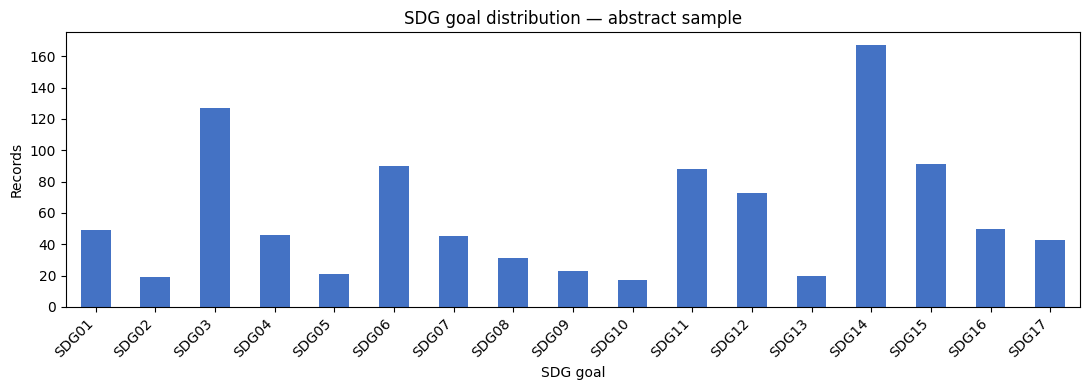

In [ ]:
# Abstract sample goal counts
plot_counts(abstracts["sdg_goal"].value_counts(), "SDG goal distribution — abstract sample", "SDG goal", "Records")

In [ ]:
# Title length
text_stats(abstracts, "title")


Text field: title


,characters,words
count,1000.000000,1000.000000
mean,102.984000,14.070000
std,40.631991,5.822113
min,10.000000,1.000000
25%,78.000000,10.000000
50%,99.000000,14.000000
75%,122.000000,17.000000
max,509.000000,83.000000


Empty text rows: 0


In [ ]:
# Abstract length
text_stats(abstracts, "abstract_cleaned")


Text field: abstract_cleaned


,characters,words
count,1000.000000,1000.000000
mean,1214.548000,177.134000
std,632.959809,92.522162
min,3.000000,1.000000
25%,815.750000,119.000000
50%,1208.000000,175.000000
75%,1619.250000,237.000000
max,4611.000000,654.000000


Empty text rows: 0


In [ ]:
years = pd.to_datetime(long["date"], errors="coerce").dt.year
display(years.value_counts().sort_index().rename_axis("year").to_frame("rows"))

,rows
year,
2010,75870
2011,85629
2012,94962
2013,110171
2014,120254
2015,129096
2016,143553
2017,161568
2018,184311
